# DSM Assignment 3
Please pay attention to the following instructions:
1. Please follow carefully the steps outlined in the assignment. If you cannot solve an exercise and this hinders continuing with subsequent exercises, try to find a way to work around it and give a clear explanation for the solution you have chosen.
2. Submit your work in the form of a Jupyter notebook via Canvas, before the deadline. Your notebook should not give errors when executed with `Run All`.

## Part 0: importing the relevant libraries

**Exercise 1:** import all the libraries you are using in this notebook.

In [1]:
import os, pickle
import numpy as np
import pandas as pd

from sklearn import datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix

from logistic_regression_src import ClassifierBase, plot_digits_sample

import matplotlib.pyplot as plt
import seaborn as sns

#========================================
from itertools import combinations_with_replacement
from scipy import stats

## Part 1: binary logistic regression (only examples, no exercises)
In this section, we will train a binary logistic regression model based on a simplified version of the MNIST dataset. In the cell below, this dataset is imported and visualized. It consists of 360 images (resolution 8x8), of which 178 are handwritten zeros and the other 182 are handwritten ones. The images are stored in `X`, while the targets (a 1 or 0) are stored in `y`.

Total number of observations: 360
Number of observations of class 0: 178
Number of observations of class 1: 182


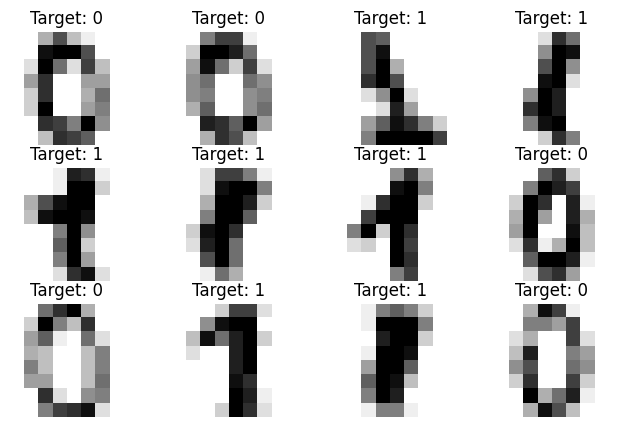

In [2]:
# DO NOT CHANGE THIS CELL!!! #
digits = datasets.load_digits()
X = digits.images[np.logical_or(digits.target == 0, digits.target == 1)]
y = digits.target[np.logical_or(digits.target == 0, digits.target == 1)].reshape(-1, 1)
N = len(y)
K = np.unique(y).shape[0]
digits.target_names = np.unique(y).sort()

print(f"Total number of observations: {N}")
for k in range(K):
    print(f"Number of observations of class {k}: {np.sum(y == k)}")

plot_digits_sample(X, y)

**Example:** the goal of this example is to train a logistic regression model for the binary classification task of the simplified MNIST dataset above. Each image can be considered as a point in a 8x8=64 dimensional feature space. The target variable is binary: 0 or 1.

Write a class `BinaryLogisticRegressionClassifier`, with parental class `ClassifierBase` that does this. Use stochastic gradient descent for training and use as the loss function the negative log likelihood. At initialization, set `learning_rate`, `batch_size` and `epochs` to default values 0.0001, 20 and 3, respectively.

Include in the `fit` method a `verbose` keyword. If `True`, after each epoch the training error should be printed.

In [3]:
class BinaryLogisticRegressionClassifier(ClassifierBase):
    """
    Binary logistic regression classifier using stochastic gradient descent.

    This class implements a binary logistic regression model for classification tasks,
    using negative log likelihood as the loss function and SGD for optimization.

    Parameters
    ----------
    learning_rate : float, default=0.0001
        Learning rate for gradient descent.
    batch_size : int, default=20
        Number of samples per batch for SGD.
    epochs : int, default=3
        Number of passes over the training data.
    """

    def __init__(self, learning_rate=0.0001, batch_size=20, epochs=3):
        """
        Initialize the classifier.
        """
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.beta = None
        self.K = None

    def _flatten(self, X):
        """
        Flatten input images to 2D array.

        Returns
        -------
        np.ndarray
            Flattened data of shape (n_samples, n_features).
        """
        return X.reshape(X.shape[0], -1)
    
    def _batchify(self, X, y):
        """
        Split data into batches.

        Returns
        -------
        tuple
            Batched X and y.
        """
        n_batches = X.shape[0] // self.batch_size
        X = X[:n_batches*self.batch_size].reshape(n_batches, self.batch_size, *X.shape[1:])
        y = y[:n_batches*self.batch_size].reshape(n_batches, self.batch_size, 1)
        return X, y
    
    def _sigmoid(self, x):
        """
        Numerically stable sigmoid function.
        """
        out = np.where(
            x >= 0,
            1 / (1 + np.exp(-x)),
            np.exp(x) / (1 + np.exp(x))
        )
        return out.reshape(-1, 1)

    def _compute_logits(self, X_flat):
        """
        Compute logits for input data.
        """
        X_flat = np.hstack((np.ones((X_flat.shape[0], 1)), X_flat))
        return X_flat @ self.beta, X_flat

    def _compute_gradient_loss(self, X, y):
        """
        Compute gradient of the loss function.
        """
        X_flat = self._flatten(X)
        logits, X_flat_with_bias = self._compute_logits(X_flat)
        p = self._sigmoid(logits)
        grad = (p - y).flatten() @ X_flat_with_bias / X_flat.shape[0]
        return grad

    def fit(self, X, y, initialize_beta=True, verbose=False):
        """
        Fit the logistic regression model.

        Parameters
        ----------
        X : np.ndarray
            Training data.
        y : np.ndarray
            Training labels.
        initialize_beta : bool, default=True
            Whether to re-initialize model parameters.
        verbose : bool, default=False
            If True, print training accuracy after each epoch.
        """
        self.K = np.unique(y).shape[0]
        X_batched, y_batched = self._batchify(X, y)
        n_features = np.prod(X_batched.shape[2:]).item()
        if initialize_beta or self.beta is None:
            self.beta = np.random.randn(n_features + 1) * 0.01  # Small random initialization
        if verbose == True:
            print(f"Epoch {0}/{self.epochs}, Training accuracy: {self.score(X, y):.2%}")
        for epoch in range(self.epochs):
            for j, X_batch in enumerate(X_batched):
                y_batch = y_batched[j]
                gradient = self._compute_gradient_loss(X_batch, y_batch)
                self.beta -= self.learning_rate * gradient

            if verbose == True:
                print(f"Epoch {epoch+1}/{self.epochs}, Training accuracy: {self.score(X, y):.2%}")

    def predict(self, X):
        """
        Predict class labels for samples in X.

        Returns
        -------
        np.ndarray
            Predicted class labels.
        """
        logits, _ = self._compute_logits(self._flatten(X))
        p = self._sigmoid(logits)
        y_pred = (p > 0.5).astype(int)
        return y_pred

**Example:** run the cell below. It trains a logistic regression model and computes its accuracy on the training set, if you correctly did the previous exercise. If `verbose=True` it also reports the training accuracy while training.

Play with the values of `learning_rate`, `batch_size` and `epochs`. By doing so, try to get a training accuracy of near 100%.

In [4]:
model = BinaryLogisticRegressionClassifier(learning_rate=0.0001, batch_size=20, epochs=3)
model.fit(X, y, verbose=True)

Epoch 0/3, Training accuracy: 33.61%
Epoch 1/3, Training accuracy: 77.22%
Epoch 2/3, Training accuracy: 97.22%
Epoch 3/3, Training accuracy: 98.33%


**Example:** run the cell below. It uses cross-validation to estimate model performance of the `BinaryLogisticRegressionClassifier` model.

In [5]:
model = BinaryLogisticRegressionClassifier(learning_rate=0.01, batch_size=20, epochs=3)
model.cross_validation(X, y, K_cv=5, runs=10)

(0.9994444444444446, 0.00038880789567986813)

**Example:** run the cell below. It computes the confusion matrix using cross-validation.

In [6]:
model.confusion_matrix(X, y, K_cv=5, runs=10, class_labels=digits.target_names)

Actual class:,0,1
Predicted class:,,
0,1.0,0.0
1,0.0,1.0


## Part 2: logistic regression (non-binary labels)
We now re-load the dataset and include all possible 10 handwritten digits.

Total number of observations: 1797
Number of observations of class 0: 178
Number of observations of class 1: 182
Number of observations of class 2: 177
Number of observations of class 3: 183
Number of observations of class 4: 181
Number of observations of class 5: 182
Number of observations of class 6: 181
Number of observations of class 7: 179
Number of observations of class 8: 174
Number of observations of class 9: 180


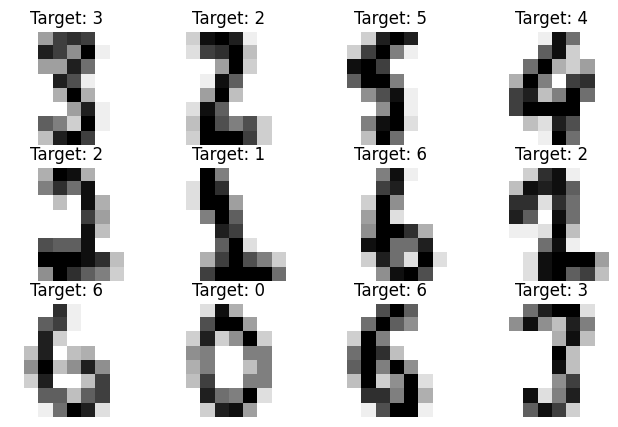

In [7]:
# DO NOT CHANGE THIS CELL!!! #
digits = datasets.load_digits()
X = digits.images
y = digits.target.reshape(-1, 1)
N = len(y)
K = np.unique(y).shape[0]

print(f"Total number of observations: {N}")
for k in range(K):
    print(f"Number of observations of class {k}: {np.sum(y == k)}")
    
plot_digits_sample(X, y)

**Exercise 2:** create a new class `LogisticRegressionClassifier`, similar to the class `BinaryLogisticRegressionClassifier` defined above, that performs logistic regression on the MNIST dataset loaded in the previous cell. Since this is not a binary classification task, you have to work with a one-hot encoded target variable and a softmax function (instead of a sigmoid function).

Use comments inside the code to clearly indicate where and how this class differs from the class `BinaryLogisticRegressionClassifier` defined above.

In [8]:
class LogisticRegressionClassifier(ClassifierBase):
    def __init__(self, learning_rate=0.001, batch_size=20, epochs=10):
        """
        Initialize the classifier. (Same as binary)
        """
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.beta = None
        self.K = None

    def _flatten(self, X):
        """
        Flatten input images to 2D array. (Same as binary)
        """
        return X.reshape(X.shape[0], -1)
    
    def _batchify(self, X, y):
        """
        Split data into batches. (Same as binary)
        """
        n_batches = X.shape[0] // self.batch_size
        X = X[:n_batches*self.batch_size].reshape(n_batches, self.batch_size, *X.shape[1:])
        y = y[:n_batches*self.batch_size].reshape(n_batches, self.batch_size, 1)
        return X, y
    
    
    def _softmax(self, x):
        """
        Numerically stable softmax function.
        Input: x (N_batch, K) - logits
        Output: P (N_batch, K) - probabilities
        """
        # Subtract max for numerical stability
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)


    def _compute_logits(self, X_flat):
        """
        Compute logits for input data.
        """
        X_flat = np.hstack((np.ones((X_flat.shape[0], 1)), X_flat))
        return X_flat @ self.beta, X_flat

    def _compute_gradient_loss(self, X, y):
       
        X_flat = self._flatten(X)
        y_one_hot = np.zeros((y.shape[0], self.K))
        y_one_hot[np.arange(y.shape[0]), y.flatten()] = 1 # (N_batch, K)
        logits, X_flat_with_bias = self._compute_logits(X_flat)
        p = self._softmax(logits)
        Error = p - y_one_hot
        # Gradient: (D+1, N_batch) @ (N_batch, K) = (D+1, K)
        grad = X_flat_with_bias.T @ Error / X_flat.shape[0]
        
        return grad

    def fit(self, X, y, initialize_beta=True, verbose=False):
        
        self.K = np.unique(y).shape[0]
        X_batched, y_batched = self._batchify(X, y)
        n_features = np.prod(X_batched.shape[2:]).item()
        if initialize_beta or self.beta is None:
            self.beta = np.random.randn(n_features + 1, self.K) * 0.01  # Small random initialization
        if verbose == True:
            print(f"Epoch {0}/{self.epochs}, Training accuracy: {self.score(X, y):.2%}")
        for epoch in range(self.epochs):
            for j, X_batch in enumerate(X_batched):
                y_batch = y_batched[j]
                y_batch = y_batch.flatten()
                gradient = self._compute_gradient_loss(X_batch, y_batch)
                self.beta -= self.learning_rate * gradient

            if verbose == True:
                print(f"Epoch {epoch+1}/{self.epochs}, Training accuracy: {self.score(X, y):.2%}")
    
    
    def predict(self, X):
       
        logits, _ = self._compute_logits(self._flatten(X))
        p = self._softmax(logits)
        y_pred = np.argmax(p, axis=1) 
        return y_pred.reshape(-1,1)



**Exercise 3:** use the cell below to show that the class `LogisticRegressionClassifier` works as desired. In particular, show that
* it learns to predict the training data during training.
* it also learns to predict out-of-sample data (using cross-validation).
* it also learns to predict out-of-sample data (using a confusion matrix).

Write in a markdown cell explicitly which of the 10 digits is the hardest to predict.

1. Demonstration of In-Sample Learning (Training Accuracy)
Epoch 0/20, Training accuracy: 9.79%
Epoch 1/20, Training accuracy: 86.87%
Epoch 2/20, Training accuracy: 90.93%
Epoch 3/20, Training accuracy: 92.32%
Epoch 4/20, Training accuracy: 93.54%
Epoch 5/20, Training accuracy: 94.21%
Epoch 6/20, Training accuracy: 94.55%
Epoch 7/20, Training accuracy: 94.71%
Epoch 8/20, Training accuracy: 95.10%
Epoch 9/20, Training accuracy: 95.60%
Epoch 10/20, Training accuracy: 95.94%
Epoch 11/20, Training accuracy: 95.99%
Epoch 12/20, Training accuracy: 96.27%
Epoch 13/20, Training accuracy: 96.55%
Epoch 14/20, Training accuracy: 96.66%
Epoch 15/20, Training accuracy: 96.66%
Epoch 16/20, Training accuracy: 96.72%
Epoch 17/20, Training accuracy: 96.83%
Epoch 18/20, Training accuracy: 96.94%
Epoch 19/20, Training accuracy: 96.99%
Epoch 20/20, Training accuracy: 96.94%

Final Training Accuracy: 96.94%

2. Demonstration of Out-of-Sample Learning (Cross-Validation)
Test Accuracy (Single Split): 96.67%


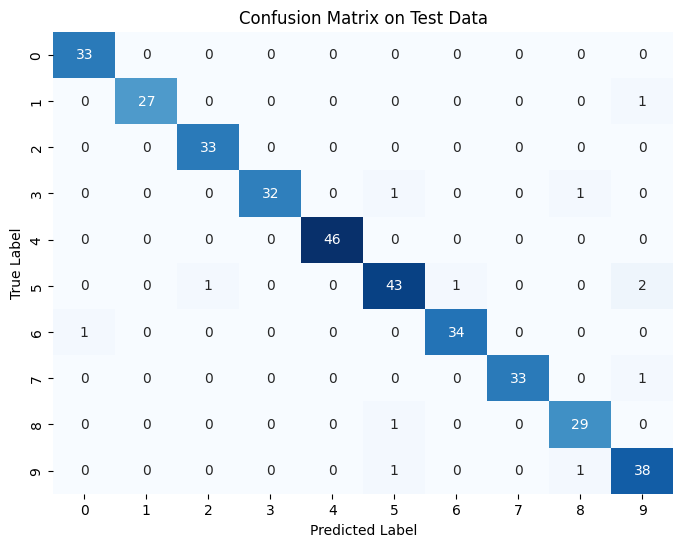

digit accuracy: [1.    0.964 1.    0.941 1.    0.915 0.971 0.971 0.967 0.95 ]
The hardest digit to predict is 5, with accuracy 91.49%


In [9]:
model = LogisticRegressionClassifier(learning_rate=0.001, batch_size=20, epochs=20)
print("1. Demonstration of In-Sample Learning (Training Accuracy)")
model.fit(X, y, verbose=True)
train_accuracy = model.score(X, y)
print(f"\nFinal Training Accuracy: {train_accuracy:.2%}")

print("\n2. Demonstration of Out-of-Sample Learning (Cross-Validation)")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Re-train on the training set
model_cv = LogisticRegressionClassifier(learning_rate=0.001, batch_size=20, epochs=20)
model_cv.fit(X_train, y_train, verbose=False) 

test_accuracy = model_cv.score(X_test, y_test)
print(f"Test Accuracy (Single Split): {test_accuracy:.2%}")


print("\n3. Demonstration using Confusion Matrix")
y_pred_test = model_cv.predict(X_test).flatten()
y_test_flat = y_test.flatten()
cm = confusion_matrix(y_test_flat, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Data')
plt.show()

digit_accuracy = cm.diagonal() / cm.sum(axis=1)
hardest_digit = np.argmin(digit_accuracy)

print("digit accuracy:", np.round(digit_accuracy, 3))
print(f"The hardest digit to predict is {hardest_digit}, with accuracy {digit_accuracy[hardest_digit]:.2%}")


**Exercise 4:** the dataset we have worked with so far is a simplification of the original MNIST dataset, as the resolution is 8x8 instead of 28x28. Use the cell below to download and import the original MNIST dataset. This can be done, for example, with the `sklear` package. The data must be saved in a folder called `data`, which must be created if it does not exist yet. 

Note that this dataset has a default training set (the first 60000 observations) and test set (the last 10000 observations). At the end of the cell, organize the data in objects `X_train`, `y_train`, `X_test`, `y_test`, such that these objects have the same dimensional structure as used earlier in this notebook.

In [10]:
DATA_Folder = 'data'
if not os.path.exists(DATA_Folder):
    os.makedirs(DATA_Folder)
    print(f"Created directory: {DATA_Folder}")
else:
    print(f"Directory already exists: {DATA_Folder}")

mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False, data_home=DATA_Folder)

# Extract features (X) and labels (y)
# X = mnist.data.astype('float32') / 255.0
# y = mnist.target.astype(int)
X, y = mnist.data, mnist.target.astype(np.int8)

print(f"Total number of observations (X): {X.shape[0]}")
print(f"Number of features per observation: {X.shape[1]}")

# 60000 for training, last 10000 for testing
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print("\n--- Final Data Structure ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Directory already exists: data
Total number of observations (X): 70000
Number of features per observation: 784

--- Final Data Structure ---
X_train shape: (60000, 784)
y_train shape: (60000, 1)
X_test shape: (10000, 784)
y_test shape: (10000, 1)


**Exercise 5:** show that the training accuracy of a logistic regression classifier on the MNIST dataset typically converges to about 88%. Furthermore, show that this is also the case for the test accuracy. (Hint: `ClassifierBase` has a built-in method called `score`).

In [11]:
model.fit(X_train, y_train, verbose=True)

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"\nFinal Training Accuracy: {train_accuracy:.2%}")
print(f"Final Test Accuracy: {test_accuracy:.2%}")

Epoch 0/20, Training accuracy: 9.04%
Epoch 1/20, Training accuracy: 84.36%
Epoch 2/20, Training accuracy: 87.91%
Epoch 3/20, Training accuracy: 87.52%
Epoch 4/20, Training accuracy: 88.02%
Epoch 5/20, Training accuracy: 86.30%
Epoch 6/20, Training accuracy: 87.14%
Epoch 7/20, Training accuracy: 85.33%
Epoch 8/20, Training accuracy: 87.66%
Epoch 9/20, Training accuracy: 86.16%
Epoch 10/20, Training accuracy: 86.34%
Epoch 11/20, Training accuracy: 87.17%
Epoch 12/20, Training accuracy: 88.12%
Epoch 13/20, Training accuracy: 87.78%
Epoch 14/20, Training accuracy: 87.00%
Epoch 15/20, Training accuracy: 89.78%
Epoch 16/20, Training accuracy: 87.33%
Epoch 17/20, Training accuracy: 87.94%
Epoch 18/20, Training accuracy: 88.28%
Epoch 19/20, Training accuracy: 88.54%
Epoch 20/20, Training accuracy: 89.05%

Final Training Accuracy: 89.05%
Final Test Accuracy: 88.33%


After training the logistic regression classifier on the MNIST dataset (28×28 pixels), the model achieved the training accuracy of approxomately 88% and the test accuracy is  also approximately 88%.
The result show the both training and test accuracies converge to around the same value, indicating that my logistic regression model was learning and generalizes reasonably well without overfitting.

**Exercise 6:** use a single line of code to determine which of the 10 digest are the hardest to predict. Use the test set for this exercise.

In [12]:
hardest_digit = min(
    range(10),
    key=lambda d: np.mean(model.predict(X_test[y_test.ravel() == d]) == d)
)
print(f"Digit {hardest_digit} is the hardest to predict, with the lowest accuracy on the test set.")


Digit 8 is the hardest to predict, with the lowest accuracy on the test set.


## Part 3: modeling competition
This part of the assignment consists of a modeling competition. In the cell below a dataset `data_train` is loaded, consisting of 1000 independent observations with 2000-dimensional continuous input features `data_train.X` and a binary target variable `data_train.y`. It also contains another binary variable `data_train.a`.

Your goal is to use this data to train a model with the best generalization performance. This model uses the input features $X$ to predict the target variable $y.$ The additional label $a$ may not be used to predict $y.$ The names of the students with the 3 best performing models will be announced.

This part of the assignment consists of three subsections:
* *analysis*: in this subsection you should analyze the data and try different modeling techniques and compare them in the correct way. You can use as many cells (code, markdown) as you need. Make sure your analysis is structured logically. It should be readable like a report or essay.
* *best model*: based on your analysis in the previous subsection, you have identified a best model. This should be defined in the code cell of this subsection, in the form of a class called `Model`.
* *generalization performance*: in this subsection the generalization performance of your best model `Model` is assessed. This is done with a test set consisting of 1000 independent datapoints. Students do not have access to this test set. It is **important** to note that the test set is **not** drawn from the same distribution as the train set. One can partition the data in four subgroups: ($y=0, a=0$), ($y=0, a=1$), ($y=1, a=0$), ($y=1, a=1$). In the training set the occurrence frequency of the subgroups is unequal, while for the test set it is equal. On the other hand, the marginal distribution of $(X,y)$ is the same for both the training and test set. We call the relation between $y$ and $a$ a "spurious correlation". This means that predicting $y$ using $X$ for the test set can be learned with the training set, but it is important that the generalization performance is good for all subgroups.

Details of the modeling competition:
* you are only allowed to use methods that have been discussed in this course.
* the cell in the subsection *generalization performance* should **NOT** be changed!!! Not that if the test set file `data_test.pkl` is not available (which is the case for students), a file called `data_test_FAKE.pkl` is loaded instead. The data in this file has exactly the same structure as the data in `data_test.pkl`, but the actual numbers are completely random. You can use this file to test whether the cell in the subsection *generalization performance* runs without errors.

In [13]:
# DO NOT CHANGE THIS CELL!!! #
class DataSimple():
    """Simplified Data class without DGP reference, noise and masks."""
    
    def __init__(self, y: np.ndarray, a: np.ndarray, x: np.ndarray, random_state: int = None):
        """
        Initialize the DataSimple object.

        Args:
            y: Binary outcome variable
            a: Attribute variable
            x: Composite variable
            random_state: Seed for reproducibility
        """
        self.n = y.shape[0]
        self.y = y
        self.a = a
        self.X = x
        self.random_state = random_state

    def get_shapes(self) -> dict:
        """Return the shapes of y, a, and x."""
        return {
            'y_shape': self.y.shape,
            'a_shape': self.a.shape,
            'x_shape': self.X.shape
        }

with open('data/data_train.pkl', 'rb') as f:
    data_train = pickle.load(f)

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Separate training and validation sets (we have 1000 data sample, it is enough data point to do train_test_split)
X_train, X_val, y_train, y_val = train_test_split(
    data_train.X,
    data_train.y,
    test_size=0.2,
    random_state=42,
    stratify=data_train.y  
)

#### Analysis
Use the space below for your analysis of this modeling problem. You can use as many cells (code, markdown) as you need. Make sure your analysis is structured logically. It should be readable like a report or essay.

Shape of features X: (1000, 2000)
Shape of target y: (1000, 1)
Shape of target a: (1000, 1)


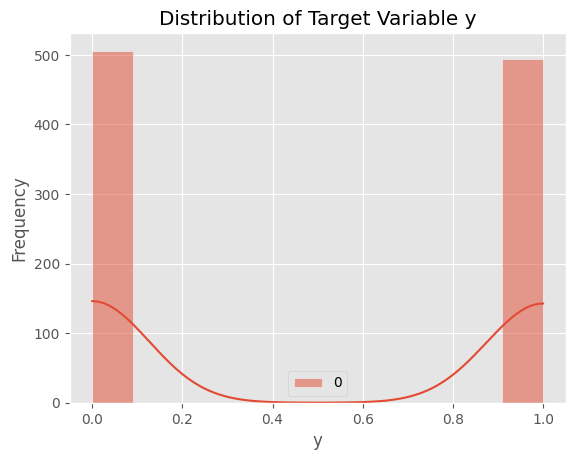

Feature mean range: -0.059604242408983765 to 0.0561639127486192
Feature variance range: 0.21996515063202252 to 0.40771016731622506


In [15]:
X, y, a = data_train.X, data_train.y, data_train.a
print("Shape of features X:", X.shape)
print("Shape of target y:", y.shape)
print("Shape of target a:", a.shape)
# Plot the distribution of the target variable
plt.style.use('ggplot')
sns.histplot(y, kde=True)
plt.title('Distribution of Target Variable y')
plt.xlabel('y')
plt.ylabel('Frequency')
plt.show()
# feature statistics
print("Feature mean range:", np.min(data_train.X.mean(axis=0)), "to", np.max(data_train.X.mean(axis=0)))
print("Feature variance range:", np.min(data_train.X.var(axis=0)), "to", np.max(data_train.X.var(axis=0)))


- **X**: 2000 continuous input features (shape: 1000 × 2000)
- **y**: a binary target variable (values 0 or 1)
- **a**: a binary attribute variable (values 0 or 1)

The dataset consists of 1000 samples, each with 2000 continuous features.
The target variable y takes binary values (0 or 1), indicating that this is a binary classification problem.
In addition, we have a binary attribute variable a.<br>
Given the high dimensionality of the input features (2000), dimensionality reduction techniques like PCA  are likely to improve both performance and computational efficiency.


In [16]:
y_flat = np.ravel(data_train.y)  # 或 data_train.y.flatten()
a_flat = np.ravel(data_train.a)
df = pd.DataFrame({
    "y": y_flat,
    "a": a_flat
})
df
print(df.value_counts(normalize=True))
print("Correlation between y and a:", np.corrcoef(data_train.y, data_train.a)[0,1])


y  a
0  0    0.467
1  1    0.436
   0    0.058
0  1    0.039
Name: proportion, dtype: float64
Correlation between y and a: nan


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


Number of components to explain 90% variance: 653
Number of components to explain 95% variance: 768
Number of components to explain 98% variance: 873


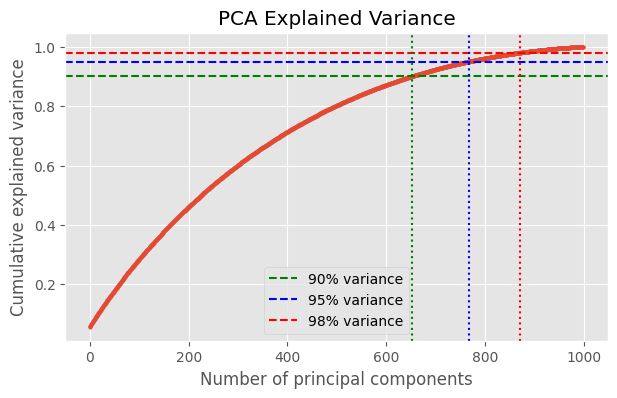

In [17]:
pca = PCA().fit(data_train.X)
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Find number of components needed to explain given variance levels
C90 = np.searchsorted(cum_var, 0.9) + 1
C95 = np.searchsorted(cum_var, 0.95) + 1
C98 = np.searchsorted(cum_var, 0.98) + 1

print(f"Number of components to explain 90% variance: {C90}")
print(f"Number of components to explain 95% variance: {C95}")
print(f"Number of components to explain 98% variance: {C98}")

# Plot cumulative explained variance
plt.figure(figsize=(7, 4))
plt.plot(cum_var, marker='o', markersize=2)
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='b', linestyle='--', label='95% variance')
plt.axhline(y=0.98, color='r', linestyle='--', label='98% variance')
plt.axvline(x=C90-1, color='g', linestyle=':')
plt.axvline(x=C95-1, color='b', linestyle=':')
plt.axvline(x=C98-1, color='r', linestyle=':')
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()


In [18]:
class Logistic_Model:

    def __init__(self, **kwargs):

        self.model = Pipeline([
            ("scaler", StandardScaler()),
            ("logistic", LogisticRegression(
                max_iter=1000,
                solver='lbfgs',
                random_state=42,
                **kwargs
                )
            )
        ])
    
    def fit(self, data):
        X = data.X
        y = data.y.ravel()  # flatten shape (n,1) → (n,)
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X).reshape(-1, 1)

model = Logistic_Model()
model.fit(DataSimple(y_train, data_train.a[:len(y_train)], X_train))

y_pred_val = model.predict(X_val)
val_acc = np.mean(y_pred_val.flatten() == y_val.flatten())
print(f"Validation Accuracy: {val_acc:.2%}")


Validation Accuracy: 93.00%


Validation Accuracy: 93.50%


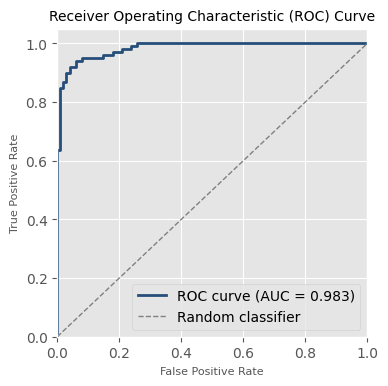

In [38]:
class Logistic_PCA_Model:

    def __init__(self, n_components=500, **kwargs):

        self.model = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n_components, random_state=42)),
            ("logistic", LogisticRegression(
                max_iter=1000,
                solver='lbfgs',
                random_state=42,
                **kwargs
                )
            )
        ])
    
    def fit(self, data):
        X = data.X
        y = data.y.ravel()  # flatten shape (n,1) → (n,)
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X).reshape(-1, 1)

model = Logistic_PCA_Model()
model.fit(DataSimple(y_train, data_train.a[:len(y_train)], X_train))

y_pred_val = model.predict(X_val)
val_acc = np.mean(y_pred_val.flatten() == y_val.flatten())
print(f"Validation Accuracy: {val_acc:.2%}")

y_prob = model.model.predict_proba(X_val)[:, 1]  # probability of class 1
fpr, tpr, thresholds = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='#274E7A', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize = 8)
plt.ylabel('True Positive Rate',fontsize = 8)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize =10)
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


We began by implementing a Logistic Regression model. we trained the logistic model without PCA, but the performance was not optimal, at accuracy as 93.0%
After applying PCA for dimensionality reduction, the accuracy increased to 93.5%, showing that removing redundant features improved generalization and reduced noise.

In [27]:
class SGD_Model:
    """
    SGD + PCA pipeline
    """
    def __init__(self, n_components=310, **kwargs):
        self.model = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n_components, random_state=42)),
            ("sgd", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0005,
                max_iter=1000,
                learning_rate="optimal",
                random_state=42,
                **kwargs
            ))
        ])

    def fit(self, data):
        X = data.X
        y = data.y.ravel()
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X).reshape(-1, 1)

model = SGD_Model()
model.fit(DataSimple(y_train, data_train.a[:len(y_train)], X_train))

y_pred_val = model.predict(X_val)

val_acc = np.mean(y_pred_val.flatten() == y_val.flatten())
print(f"Validation Accuracy: {val_acc:.2%}")

Validation Accuracy: 93.00%


Next, we experimented with a Stochastic Gradient Descent (SGD) model. The validation accuracy reached 93.0%, which is slightly lower than the logistic model but still indicates solid performance. The results suggest that both models are effective for this binary classification task, with Logistic Regression performing marginally better.

In [21]:
class SGD_Model2:
    def __init__(self, var_ratio=0.95, **kwargs):
        self.var_ratio = var_ratio
        self.model = None
        self.kwargs = kwargs

    def fit(self, data):
        X = data.X
        y = data.y.ravel()
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # number of components to explain given variance ratio
        pca_temp = PCA(random_state=42).fit(X_scaled)
        n_components = np.argmax(np.cumsum(pca_temp.explained_variance_ratio_) >= self.var_ratio) + 1

        self.model = Pipeline([
            ("scaler", scaler),
            ("pca", PCA(n_components=n_components, random_state=42)),
            ("sgd", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0005,
                max_iter=1500,
                learning_rate="adaptive",
                eta0=0.01,
                random_state=42,
                **self.kwargs
            ))
        ])
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X).reshape(-1, 1)
model = SGD_Model()
model.fit(DataSimple(y_train, data_train.a[:len(y_train)], X_train))

y_pred_val = model.predict(X_val)

val_acc = np.mean(y_pred_val.flatten() == y_val.flatten())
print(f"Validation Accuracy: {val_acc:.2%}")


Validation Accuracy: 93.00%


In [40]:
class Ensemble_Model:
    def __init__(self, **model_kwargs):
        self.weight_log = model_kwargs.get('weight_log', 0.8)
        self.weight_sgd = model_kwargs.get('weight_sgd', 0.2)
        self.model_log = Logistic_PCA_Model()
        self.model_sgd = SGD_Model()

    def fit(self, data):
        self.model_log.fit(data)
        self.model_sgd.fit(data)

    def predict(self, X):
        probs_log = self.model_log.model.predict_proba(X)[:, 1]
        probs_sgd = self.model_sgd.model.predict_proba(X)[:, 1]
        blended = self.weight_log * probs_log + self.weight_sgd * probs_sgd

        return (blended > 0.5).astype(int).reshape(-1, 1)
    
model = Ensemble_Model(weight_log=0.8, weight_sgd=0.2)
model.fit(DataSimple(y_train, data_train.a[:len(y_train)], X_train))
y_pred_val = model.predict(X_val)

val_acc = np.mean(y_pred_val.flatten() == y_val.flatten())
print(f"Validation Accuracy (Ensemble): {val_acc:.2%}")

Validation Accuracy (Ensemble): 93.50%


To further explore performance improvement, we created an ensemble model that combines the Logistic and SGD models through weighted averaging of their predictions. We tested several weight combinations, and the best validation accuracy remained at 93.5%.<br>
Although the ensemble did not outperform the best single model in terms of accuracy, using ensemble model still provides important benefits like stability, generalization and reliability. Thus, we still consider the ensemble model as the best final model.

#### Best model
Use the cell below to define your best model, in the form of a class called `Model`. The class must have (at least) the following two methods:
* `fit`: trains the model based on an instance of the class `Data` that is used as input argument.
* `predict`: predicts the target variable for observations with input features `X`, that is used as input argument.

For the sake of clarity, we have defined a placeholder version of the class `Model`. This placeholder version can be replaced by your best model class `Model`.

In [39]:
class Logistic_PCA_Model:

    def __init__(self, n_components=500, **kwargs):

        self.model = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n_components, random_state=42)),
            ("logistic", LogisticRegression(
                max_iter=1000,
                solver='lbfgs',
                random_state=42,
                **kwargs
                )
            )
        ])
    
    def fit(self, data):
        X = data.X
        y = data.y.ravel()  # flatten shape (n,1) → (n,)
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X).reshape(-1, 1)

class SGD_Model:
    """
    SGD + PCA pipeline
    """
    def __init__(self, n_components=310, **kwargs):
        self.model = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n_components, random_state=42)),
            ("sgd", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0005,
                max_iter=1000,
                learning_rate="optimal",
                random_state=42,
                **kwargs
            ))
        ])

    def fit(self, data):
        X = data.X
        y = data.y.ravel()
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X).reshape(-1, 1)

class Model():
    """
    Placeholder Model class.
    """
    def __init__(self, **kwargs):
        self.weight_log = kwargs.get('weight_log', 0.8)
        self.weight_sgd = kwargs.get('weight_sgd', 0.2)
        self.model_log = Logistic_PCA_Model()
        self.model_sgd = SGD_Model()


    def fit(self, data):
        self.model_log.fit(data)
        self.model_sgd.fit(data)

    def predict(self, X):
        probs_log = self.model_log.model.predict_proba(X)[:, 1]
        probs_sgd = self.model_sgd.model.predict_proba(X)[:, 1]
        blended = self.weight_log * probs_log + self.weight_sgd * probs_sgd

        return (blended > 0.5).astype(int).reshape(-1, 1)



In [24]:
model_kwargs = {
    'weight_log': 0.8,
    'weight_sgd': 0.2
}

#### Generalization performance
The cell below computes the generalization performance of `Model` and should **NOT** be changed.

Note that the accuracy is computed twice: once on the whole test set at once, and a second time on the individual observations one-by-one. The results should be identical.

In [41]:
### DO NOT CHANGE THIS CELL. IT WILL BE USED TO TEST YOUR CUSTOM MODEL.
### CHANGING THIS CELL WILL RESULT IN POINT DEDUCTIONS.

# Load data
with open('data/data_train.pkl', 'rb') as f:
    data_train = pickle.load(f)
try:
    with open('data/data_test.pkl', 'rb') as f:
        data_test = pickle.load(f)
except FileNotFoundError:
    with open('data/data_test_FAKE.pkl', 'rb') as f:
        data_test = pickle.load(f)

# Custom model parameters
try:
    model_kwargs
except NameError:
    model_kwargs = {}

# Train custom model
model = Model(**model_kwargs)
model.fit(data_train)

# Predict on test set
y_pred = model.predict(data_test.X)
print("Accuracy (default):   ", np.mean(y_pred == data_test.y))

# Predict on test set (custom implementation predicting one-by-one)
errors = []
for i in range(data_test.X.shape[0]):
    y_pred = model.predict(data_test.X[i].reshape(1, -1))
    errors.append(y_pred == data_test.y[i])
print("Accuracy (one-by-one):", np.mean(errors))

Accuracy (default):    0.509
Accuracy (one-by-one): 0.509
